In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/AppliedTimeSeriesAnalysisWithPython/main/data/jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [2]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [3]:
# 마지막 4개 제외 모든 데이터
train = df[:-4]
# 마지막 4개만 포함
test = df[-4:]

# 과거 평균 기반 베이스라인

In [4]:
import numpy as np

historical_mean = np.mean(train['data'])

print(historical_mean)

4.308499987499999


In [6]:
test.loc[:, 'pred_mean'] = historical_mean

## Test Accuracy

### MAPE Function

In [7]:
# y_true라는 관측된 실젯값을 포함하는 벡터형 매개변수와 y_pred라는 예측값을 포함하는
# 벡터형 매개변수
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    # y_true - y_pred: 이러면 백분율 오차를 얻을 수 있음
    # (np.abs((y_true - y_pred) / y_true)): 절댓값을 얻은 후 평균 

In [ ]:
# 베이스라인 모델의 MAPE
mape_hist_mean = mape(test['data'], test['pred_mean'])
print(mape_hist_mean)

#결과: 베이스라인 모델 예측값이 1980년에 관측된 J&J의 분기별 주당순이익 실젯값에 비해 평균적으로 70% 정도 벗어나는
# 결과를 보인다는것

70.00752579965119


# Visualize

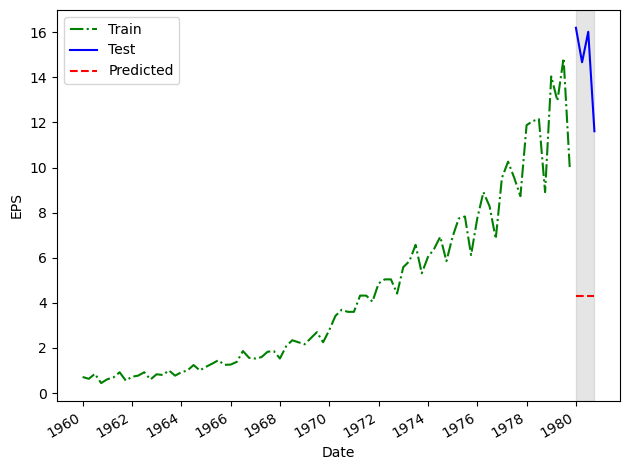

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label = 'Train')
ax.plot(test['date'], test['data'], 'b-', label = "Test")
ax.plot(test['date'], test['pred_mean'], 'r--', label = "Predicted") #예측값
ax.set_xlabel('Date')
ax.set_ylabel('EPS')
ax.axvspan(80, 83, color = '#808080', alpha = 0.2)
ax.legend(loc = 2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972,
                                1974, 1976, 1978, 1980])

# x축 눈금 레이블의 서식을 자동 설정; 레이블 약간 회전시켜 가독성 향상
fig.autofmt_xdate()
plt.tight_layout()

* 과거의 평균값 기반 베이스라인 모델로 예측.
* 예측값과 테스트 집핪의 실젯값 거리가 멀다.

- 하지만 아래와 같이 양의 추세 존재. 60-80년 사이 가파르게 증가.
![alt text](Screenshots/2.7.png)

# (2.3) 작년의 평균으로 예측 </br>
*train 집합 중 직전 연도 데이터를 쓰면 어떨까?*

In [ ]:
# 1979년 4번의 분기에 대한 EPS의 평균을 계산; train의 마지막 4개 요소의 평균 계산
last_year_mean = np.mean(train.data[-4:]) #마지막 4번([-4:])의 분기에 관한 평균

print(last_year_mean)
# 결과: 1980년 4번의 분기 동안 주당순이익을 12.96으로 예측할 수 있음.

12.96


In [12]:
# pred__last_yr_mean 열 만들어 저장
test.loc[:, 'pred__last_yr_mean'] = last_year_mean
test

,date,data,pred_mean,pred__last_yr_mean
80,1980-01-01,16.20,4.3085,12.96
81,1980-04-01,14.67,4.3085,12.96
82,1980-07-02,16.02,4.3085,12.96
83,1980-10-01,11.61,4.3085,12.96


In [ ]:
# MAPE 통해 베이스라인 재계산
mape_last_year_mean = mape(test['data'], test['pred__last_yr_mean'])

print(mape_last_year_mean)

15.5963680725103


## Visualization

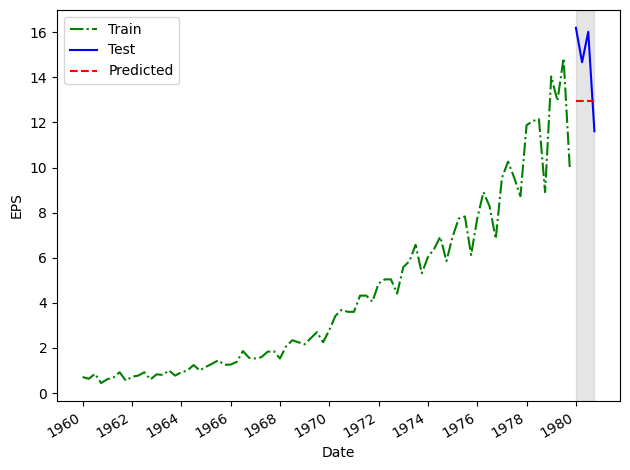

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label = 'Train')
ax.plot(test['date'], test['data'], 'b-', label = "Test")
#이제는 pred_mean이 아니라 pred__last_yr_mean
ax.plot(test['date'], test['pred__last_yr_mean'], 'r--', label = "Predicted")
ax.set_xlabel('Date')
ax.set_ylabel('EPS')
ax.axvspan(80, 83, color = '#808080', alpha = 0.2)
ax.legend(loc = 2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972,
                                1974, 1976, 1978, 1980])

# x축 눈금 레이블의 서식을 자동 설정; 레이블 약간 회전시켜 가독성 향상
fig.autofmt_xdate()
plt.tight_layout()

# 마지막으로 측정된 값으로 예측

In [ ]:
# 이전 베이스라인을 통해:
# "미랫값은 과거값과 연관이 있지만, '너무' 먼 과것값과는 연관성이 떨어진다"
# Why? MAPE가 훨씬 줄어들었음.
# --> autocorrelation의 징조

# 그래서 train 데이터 중 마지막 값을 베이스라인 모델로 사용한다면?
# 가설: 더 나은 예측이 있지 않을까?

In [16]:
# train 집합에서 마지막으로 측정된 값을 추출 (1979년 마지막 분기)
last = train.data.iloc[-1]

print(last)
# 가설에 배경하면, 1980년 4분기 EPS는 $9.99가 될것

9.99


In [18]:
# 예측값 저장
test.loc[:, 'pred_last'] = last
test

,date,data,pred_mean,pred__last_yr_mean,pred_last
80,1980-01-01,16.20,4.3085,12.96,9.99
81,1980-04-01,14.67,4.3085,12.96,9.99
82,1980-07-02,16.02,4.3085,12.96,9.99
83,1980-10-01,11.61,4.3085,12.96,9.99


In [19]:
#MAPE 통해 새로운 베이스라인 모델의 성능 평가
mape_last = mape(test['data'], test['pred_last'])

print(mape_last)

30.457277908606535


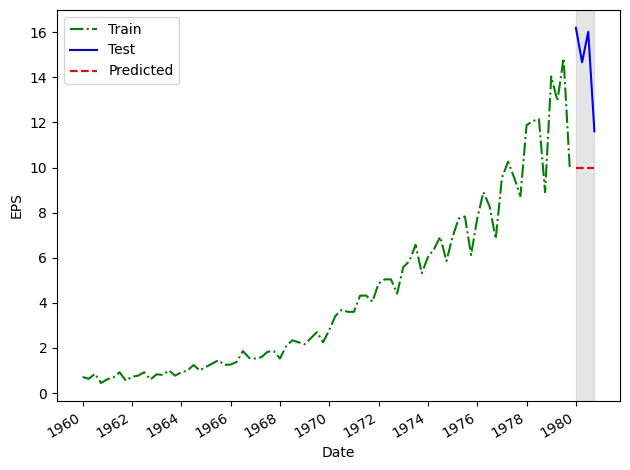

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label = 'Train')
ax.plot(test['date'], test['data'], 'b-', label = "Test")
#이제는 pred_mean이 아니라 pred__last_yr_mean
ax.plot(test['date'], test['pred_last'], 'r--', label = "Predicted")
ax.set_xlabel('Date')
ax.set_ylabel('EPS')
ax.axvspan(80, 83, color = '#808080', alpha = 0.2)
ax.legend(loc = 2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972,
                                1974, 1976, 1978, 1980])

# x축 눈금 레이블의 서식을 자동 설정; 레이블 약간 회전시켜 가독성 향상
fig.autofmt_xdate()
plt.tight_layout()

- 결과: 처음 3번의 분기 동안은 높았다가 마지막 분기에 하락하는 주기적인 행동을 보인다는 점을 원인으로.
- 마지막 측정된 값: 계절성을 반영하지 않아 좋지 않은 결과에 도달

# (2.5) 단순한 계절적 예측 구현하기 </br>
*주기적 패턴을 분명하게* </br>
![alt text](Screenshots/2.10.png) </br></br>


In [22]:
# 주기의 길이는 4번의 분기이므로 1979년 첫 번째 분기의 EPS를 사용하여 1980년 첫 번째 분기의 값을 예측
# 그 다음 1979년 두 번째 분기의 EPS를 사용해 1980년 두 번째 분기의 값을 예측

# 1979년 4번의 분기에 해당하는 마지막 4개 값을 가져온 후, 
# 1980년의 분기들에 순서대로 값을 할당하는 방식으로 베이스라인 모델을 구현

test.loc[:, 'pred_last_season'] = train['data'][-4:].values
test

,date,data,pred_mean,pred__last_yr_mean,pred_last,pred_last_season
80,1980-01-01,16.20,4.3085,12.96,9.99,14.04
81,1980-04-01,14.67,4.3085,12.96,9.99,12.96
82,1980-07-02,16.02,4.3085,12.96,9.99,14.85
83,1980-10-01,11.61,4.3085,12.96,9.99,9.99


In [23]:
mape_naive_seasonal = mape(test['data'], test['pred_last_season'])

print(mape_naive_seasonal)

11.561658552433654


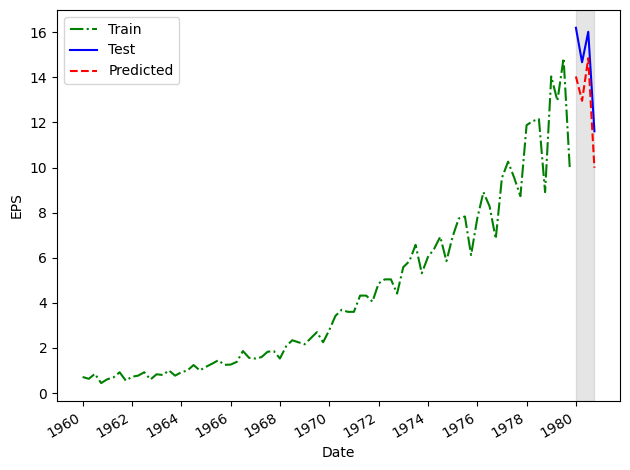

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label = 'Train')
ax.plot(test['date'], test['data'], 'b-', label = "Test")
#이제는 pred_mean이 아니라 pred__last_yr_mean
ax.plot(test['date'], test['pred_last_season'], 'r--', label = "Predicted")
ax.set_xlabel('Date')
ax.set_ylabel('EPS')
ax.axvspan(80, 83, color = '#808080', alpha = 0.2)
ax.legend(loc = 2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972,
                                1974, 1976, 1978, 1980])

# x축 눈금 레이블의 서식을 자동 설정; 레이블 약간 회전시켜 가독성 향상
fig.autofmt_xdate()
plt.tight_layout()

- 지난 계절의 관측값이 미래에 반복해서 일어난다고 예측하는 가설이 정확했음
- 계절성이 미래에 상당한 영향을 미친다.